# Multimodal AutoML LOOCV — SC + FC84 **Joint PCA**  [pass]

기존 `Multimodal`은 SC와 FC를 **따로** PCA로 줄인 뒤 붙였다 (SC PCA3 + FC PCA3 = 6개).
이 노트북은 순서를 바꿔 **먼저 붙이고 PCA를 한 번** 돌린다 (SC 84 + FC 84 = 168 → PCA3).
`multimodal_msn_fc68/automl_multimodal_MSN_FC68_joint_PCA3.ipynb`의 설계를 SC + FC에 그대로 옮긴 것이다.

| | 따로 PCA (`Multimodal`) | Joint PCA (`Joint_PCA3`) |
|---|---|---|
| 순서 | 모달리티별 PCA → hstack | hstack → PCA |
| 뇌 피처 수 | 3 + 3 = 6 | 3 |
| 성분 의미 | 구조 연결 요약 3개 + 기능 연결 요약 3개 | 두 모달리티에 걸쳐 같이 변하는 방향 3개 |
| 위험 | — | 내부 상관이 강한 모달리티가 성분을 독차지할 수 있음 |

뼈대(6개 모델 · LOOCV · nested GridSearchCV · fold 안에서 residualize → scale → PCA)는 같은 폴더의 coupling 노트북과 같다.

## Joint PCA 파이프라인 (fold 안, train에서만 fit)
1. SC strength 84 (log(1 + count)): age, sex, eTIV 잔차 → 표준화
2. FC strength 84: age, sex, mean_fd 잔차 → 표준화
3. hstack (168) → PCA 3

1–2는 `Multimodal`과 완전히 같고 **PCA 단계만 다르다.** 두 블록 모두 84개 × 단위분산이라 총분산은 같지만,
한쪽 영역끼리 더 강하게 상관돼 있으면 그쪽이 상위 PC를 가져간다 → 8번 셀에서 PC별 SC/FC 비중을 확인한다.

## 데이터 / 표본
`../sc_dk84/sc_strength_84_pass.csv`, `../fc_strength_68_16.csv` · SC 45명 ∩ FC 44명 = **공통 44명** (sub-001은 FC 없음).
타겟 `vas_t1`, 임상 `vas_t0` + `treatment_group`.

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | 뇌 피처 |
|---|---|
| `Clinical_ONLY` | 없음 |
| `SC_PCA3` | SC strength 84 (log) → PCA 3 |
| `FC84_PCA3` | FC strength 84 → PCA 3 |
| `Multimodal` | SC PCA3 + FC84 PCA3 (따로 PCA 후 결합, 6개) |
| `Joint_PCA3` | SC 84 + FC 84 결합 → PCA 3 |

PCA 성분 수 3은 기존 노트북과 맞춘 값이다.
`SC_PCA3` / `FC84_PCA3` / `Multimodal`은 같은 폴더의 coupling 노트북과 같은 계산이라, 같은 연결 기준끼리는 값이 같아야 한다 (확인용).

## 연결 기준: **pass** — streamline이 두 영역을 모두 지나가면 연결로 센다 (DSI Studio 기본값). **주 분석**

SC는 "무엇을 연결로 세느냐"에 따라 값이 크게 달라진다. 같은 사람들로 구한 영역별 coupling의 pass와 end 사이
상관이 0.525였다. 그래서 같은 분석을 두 기준으로 따로 만들었고(`..._pass.ipynb`, `..._end.ipynb`),
**주 분석은 pass, end는 민감도 분석**으로 결과를 보기 전에 정해 두었다. 어느 쪽이 좋게 나오든 둘 다 보고한다.

## 읽을 때 주의

- 잔차화 직전에 nuisance를 train 기준으로 표준화한다. 잔차는 수학적으로 같고, eTIV(백만 단위)로 인한 계산 정밀도
  문제를 막는다 (같은 폴더의 coupling 노트북과 동일).
- **이 노트북은 결과를 본 뒤에 추가한 변형이다.** `SC PCA3 + FC PCA3` 결합이 end 기준에서 좋게 나온 것을 확인한 다음 만들었다.
  미리 정한 분석이 아니므로 탐색적 결과로 읽고, pass와 end를 둘 다 보고한다.


In [1]:
import os
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피.
# LOCALAPPDATA는 사용자 이름(한글)이 들어가 있어 안 되므로 ASCII 경로를 직접 쓴다 (FC 노트북과 동일).
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (SC 84 + FC 84, rid 기준 결합)
# ==========================================================
DATA_DIR = '..'            # 데이터 CSV는 TMS 루트와 sc_dk84/ 에 있다
SC_RULE = 'pass'           # 'pass'(지나가면 셈, 주 분석) 또는 'end'(끝점 기준, 민감도 분석)

def load(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name), skipinitialspace=True)
    d.columns = d.columns.str.strip()
    return d

sc_s = load(f'sc_dk84/sc_strength_84_{SC_RULE}.csv')   # 앞 7열: rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV
fc_s = load('fc_strength_68_16.csv')                    # 앞 7열: ... mean_fd

# --- ROI 매칭 확인: 접미사만 떼면 이름과 순서가 같아야 한다 ---
N_ROI = 84
ROIS = [c[:-len('_sc')] for c in sc_s.columns[7:]]
assert len(ROIS) == N_ROI, len(ROIS)
assert [c[:-len('_fc')] for c in fc_s.columns[7:]] == ROIS, 'strength ROI 순서 불일치'

# --- 임상 변수는 두 파일 모두 structural CSV에서 왔으므로 공통 44명에서 같아야 한다 ---
chk = sc_s.merge(fc_s, on='rid', suffixes=('_s', '_f'))
for c in ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex']:
    assert np.allclose(chk[f'{c}_s'], chk[f'{c}_f']), c

# --- rid inner join: 공통 44명 (SC에만 있는 sub-001이 빠진다) ---
df = (sc_s.merge(fc_s[['rid', 'mean_fd'] + list(fc_s.columns[7:])], on='rid', how='inner')
      .sort_values('rid').reset_index(drop=True))
assert len(df) == 44, len(df)

X_sc       = np.log1p(df[[f'{r}_sc' for r in ROIS]].values)   # SC를 피처로 쓸 때는 log(1 + count) (Tong 2026)
X_fc       = df[[f'{r}_fc' for r in ROIS]].values
X_nuis_sc  = df[['age', 'sex', 'eTIV']].values
X_nuis_fc  = df[['age', 'sex', 'mean_fd']].values
X_clinical = df[['vas_t0', 'treatment_group']].values
y          = df['vas_t1'].values
group      = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

print(f'연결 기준 {SC_RULE}  |  n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'SC strength {X_sc.shape[1]} | FC strength {X_fc.shape[1]} | joint {X_sc.shape[1] + X_fc.shape[1]}')

연결 기준 pass  |  n = 44  |  Active 25 / Sham 19
SC strength 84 | FC strength 84 | joint 168


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA = 3   # 기존 노트북과 동일. Joint도 같은 3개

DATA_TYPES = ['Clinical_ONLY', 'SC_PCA3', 'FC84_PCA3', 'Multimodal', 'Joint_PCA3']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 모달리티별 nuisance residualization → scale 까지 공통, 그 뒤
#      - Multimodal : 모달리티별 PCA3 → stack   (3 + 3 = 6)
#      - Joint_PCA3 : stack (84 + 84 = 168) → PCA3 한 번   (3)
#    → StandardScaler → 모델
#    ※ 5 datasets x 6 models x 44 folds — 수 분 ~ 수십 분 소요
# ==========================================================
def resid_scale(X, N, tr, te):
    """nuisance 회귀 잔차 → 표준화. nuisance 표준화, 회귀, 피처 표준화 모두 train에서만 fit한다.

    nuisance를 먼저 표준화한다. 잔차는 수학적으로 같지만, eTIV(백만 단위)가 그대로 들어가면
    계산 정밀도 문제가 생길 수 있다 (같은 폴더의 coupling 노트북과 동일).
    """
    nz = StandardScaler().fit(N[tr])
    reg = LinearRegression().fit(nz.transform(N[tr]), X[tr])
    X_tr = X[tr] - reg.predict(nz.transform(N[tr]))
    X_te = X[te] - reg.predict(nz.transform(N[te]))
    sc = StandardScaler().fit(X_tr)
    return sc.transform(X_tr), sc.transform(X_te)

def fit_pca(Z_tr, Z_te):
    """PCA(N_PCA)를 train에서만 fit."""
    pca = PCA(n_components=N_PCA, random_state=42).fit(Z_tr)
    return pca.transform(Z_tr), pca.transform(Z_te), pca

N_SC = X_sc.shape[1]
loo = LeaveOneOut()
predictions     = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
evr_log = {'SC': [], 'FC84': [], 'Joint': []}
sc_share_log = []   # fold별, Joint PC마다 loading 제곱합 중 SC 84개가 차지하는 비중
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_sc)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr = y[tr]
    y_true.append(y[te][0])

    Zs_tr, Zs_te = resid_scale(X_sc, X_nuis_sc, tr, te)
    Zf_tr, Zf_te = resid_scale(X_fc, X_nuis_fc, tr, te)

    Xs_tr, Xs_te, pca_s = fit_pca(Zs_tr, Zs_te)
    Xf_tr, Xf_te, pca_f = fit_pca(Zf_tr, Zf_te)
    Xj_tr, Xj_te, pca_j = fit_pca(np.hstack([Zs_tr, Zf_tr]), np.hstack([Zs_te, Zf_te]))

    evr_log['SC'].append(pca_s.explained_variance_ratio_.sum())
    evr_log['FC84'].append(pca_f.explained_variance_ratio_.sum())
    evr_log['Joint'].append(pca_j.explained_variance_ratio_.sum())
    sc_share_log.append((pca_j.components_[:, :N_SC] ** 2).sum(1))   # PC는 단위벡터라 SC + FC = 1

    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]

    feat_sets = {
        'Clinical_ONLY': (Xc_tr, Xc_te),
        'SC_PCA3':       (np.hstack([Xs_tr, Xc_tr]),        np.hstack([Xs_te, Xc_te])),
        'FC84_PCA3':     (np.hstack([Xf_tr, Xc_tr]),        np.hstack([Xf_te, Xc_te])),
        'Multimodal':    (np.hstack([Xs_tr, Xf_tr, Xc_tr]), np.hstack([Xs_te, Xf_te, Xc_te])),
        'Joint_PCA3':    (np.hstack([Xj_tr, Xc_tr]),        np.hstack([Xj_te, Xc_te])),
    }

    for dt in DATA_TYPES:
        Xtr_raw, Xte_raw = feat_sets[dt]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        for name, model in models.items():
            gcv = GridSearchCV(model, param_grids[name], cv=3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
            gcv.fit(Xtr, y_tr)
            predictions[(dt, name)].append(float(gcv.best_estimator_.predict(Xte)[0]))
            best_params_log[(dt, name)].append(str(gcv.best_params_))

y_true = np.array(y_true)
print("\n\nLOOCV done.")
print('PCA3 누적 설명분산 평균: ' +
      '  |  '.join(f'{k} {np.mean(v):.1%}' for k, v in evr_log.items()))

Starting LOOCV: 6 models x 5 datasets x 44 folds ...





LOOCV done.
PCA3 누적 설명분산 평균: SC 31.0%  |  FC84 76.5%  |  Joint 48.1%


In [5]:
# ==========================================================
# 4. EVALUATION  (overall + Active/Sham)
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

rows = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in [('Overall', np.ones(len(y_true), bool)),
                     ('Active', group == 'Active'),
                     ('Sham',   group == 'Sham')]:
        rows.append({'Data Type': dt, 'Model': name, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res = pd.DataFrame(rows)

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음\n")

# --- overall RMSE 표: 행 = 모델, 열 = 피처셋 / d = 양수면 오른쪽(뒤) 조건이 이득 ---
ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
D_COLS = {
    'd_Joint_vs_Multi': ('Multimodal',    'Joint_PCA3'),
    'd_Joint_vs_SC':    ('SC_PCA3',       'Joint_PCA3'),
    'd_Joint_vs_FC84':  ('FC84_PCA3',     'Joint_PCA3'),
    'd_Joint_vs_Clin':  ('Clinical_ONLY', 'Joint_PCA3'),
    'd_Multi_vs_Clin':  ('Clinical_ONLY', 'Multimodal'),
}
for col, (a, b) in D_COLS.items():
    ov[col] = ov[a] - ov[b]

print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========")
for col in D_COLS:
    n_pos = int((ov[col] > 0).sum())
    lin = int((ov.loc[['LinearRegression', 'ElasticNet', 'SVR_Linear', 'SVR_RBF'], col] > 0).sum())
    print(f"  {col:17s} {n_pos}/6   (선형·커널 4개 중 {lin})")
print("  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음



========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,SC_PCA3,FC84_PCA3,Multimodal,Joint_PCA3,d_Joint_vs_Multi,d_Joint_vs_SC,d_Joint_vs_FC84,d_Joint_vs_Clin,d_Multi_vs_Clin
Model,,,,,,,,,,
LinearRegression,1.997,1.978,2.013,1.965,2.048,-0.083,-0.071,-0.036,-0.051,0.032
ElasticNet,1.996,1.982,2.082,1.958,2.027,-0.069,-0.046,0.054,-0.031,0.038
SVR_Linear,2.041,1.958,1.953,1.985,1.972,0.012,-0.014,-0.019,0.068,0.056
SVR_RBF,2.208,2.115,2.118,2.267,2.087,0.180,0.029,0.032,0.122,-0.059
RandomForest,2.201,2.245,2.290,2.274,2.303,-0.028,-0.058,-0.012,-0.102,-0.074
XGBoost,2.235,2.252,2.311,2.313,2.035,0.279,0.217,0.276,0.200,-0.078



========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========
  d_Joint_vs_Multi  3/6   (선형·커널 4개 중 2)
  d_Joint_vs_SC     2/6   (선형·커널 4개 중 1)
  d_Joint_vs_FC84   3/6   (선형·커널 4개 중 2)
  d_Joint_vs_Clin   3/6   (선형·커널 4개 중 2)
  d_Multi_vs_Clin   3/6   (선형·커널 4개 중 3)
  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.

========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,RMSE,R2,r,p
0,FC84_PCA3,SVR_Linear,1.9533,0.2509,0.5177,0.0003
1,SC_PCA3,SVR_Linear,1.9581,0.2472,0.5061,0.0005
2,Multimodal,ElasticNet,1.9585,0.2469,0.5136,0.0004
3,Multimodal,LinearRegression,1.9651,0.2418,0.5158,0.0003
4,Joint_PCA3,SVR_Linear,1.9721,0.2364,0.4987,0.0006
5,SC_PCA3,LinearRegression,1.9778,0.2320,0.4974,0.0006
6,SC_PCA3,ElasticNet,1.9815,0.2291,0.4819,0.0009
7,Multimodal,SVR_Linear,1.9846,0.2267,0.4847,0.0009
8,Clinical_ONLY,ElasticNet,1.9962,0.2176,0.4778,0.0010
9,Clinical_ONLY,LinearRegression,1.9973,0.2167,0.4784,0.0010


In [6]:
# ==========================================================
# 5. Active vs Sham  —  피처셋 x 모델 x scope
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,SC_PCA3,FC84_PCA3,Multimodal,Joint_PCA3
Model,,,,,
LinearRegression,1.997,1.978,2.013,1.965,2.048
ElasticNet,1.996,1.982,2.082,1.958,2.027
SVR_Linear,2.041,1.958,1.953,1.985,1.972
SVR_RBF,2.208,2.115,2.118,2.267,2.087
RandomForest,2.201,2.245,2.290,2.274,2.303
XGBoost,2.235,2.252,2.311,2.313,2.035



===== Active  RMSE =====


Data Type,Clinical_ONLY,SC_PCA3,FC84_PCA3,Multimodal,Joint_PCA3
Model,,,,,
LinearRegression,2.004,2.009,2.000,1.981,2.052
ElasticNet,2.003,2.010,2.075,1.936,2.019
SVR_Linear,2.055,1.922,1.952,2.050,1.973
SVR_RBF,2.291,2.155,2.130,2.273,2.137
RandomForest,2.261,2.368,2.440,2.409,2.498
XGBoost,2.341,2.362,2.396,2.363,2.093



===== Sham  RMSE =====


Data Type,Clinical_ONLY,SC_PCA3,FC84_PCA3,Multimodal,Joint_PCA3
Model,,,,,
LinearRegression,1.989,1.937,2.029,1.944,2.043
ElasticNet,1.988,1.943,2.090,1.988,2.039
SVR_Linear,2.022,2.005,1.955,1.895,1.971
SVR_RBF,2.095,2.061,2.103,2.259,2.018
RandomForest,2.118,2.071,2.077,2.084,2.017
XGBoost,2.089,2.098,2.195,2.246,1.955


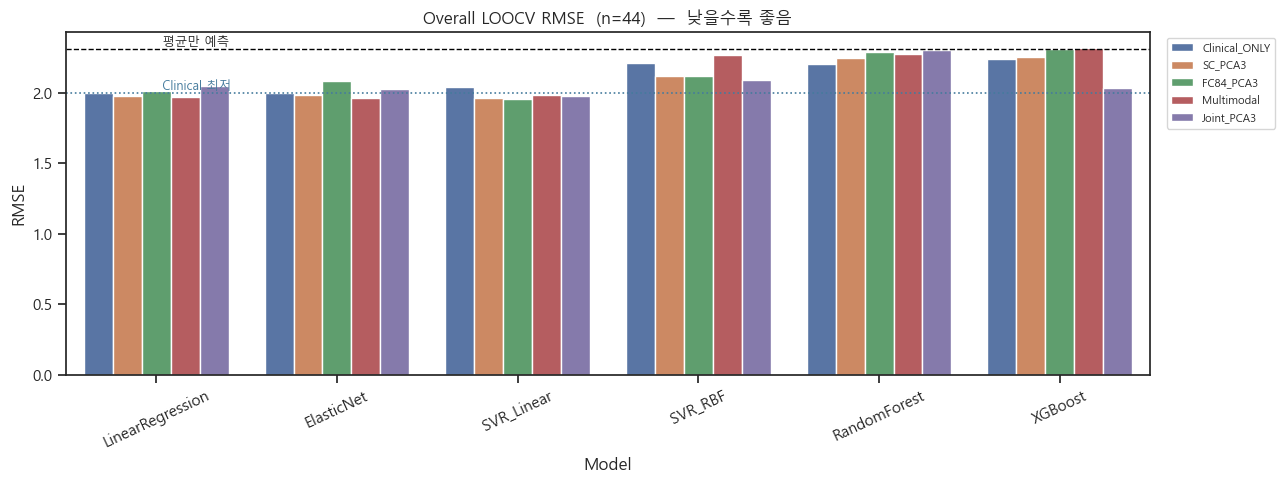

In [7]:
# ==========================================================
# 6. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  낮을수록 좋음')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 7. 하이퍼파라미터 안정성
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost] 고유 4개, 최빈 86%
[SC_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[SC_PCA3 / ElasticNet] 고유 4개, 최빈 91%
[SC_PCA3 / SVR_Linear] 고유 12개, 최빈 32%   <-- 불안정
[SC_PCA3 / SVR_RBF] 고유 6개, 최빈 82%
[SC_PCA3 / RandomForest] 고유 12개, 최빈 20%   <-- 불안정
[SC_PCA3 / XGBoost] 고유 6개, 최빈 70%
[FC84_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[FC84_PCA3 / ElasticNet] 고유 6개, 최빈 36%   <-- 불안정
[FC84_PCA3 / SVR_Linear] 고유 12개, 최빈 23%   <-- 불안정
[FC84_PCA3 / SVR_RBF] 고유 15개, 최빈 30%   <-- 불안정
[FC84_PCA3 / RandomForest] 고유 7개, 최빈 84%
[FC84_PCA3 / XGBoost] 고유 9개, 최빈 36%   <-- 불안정
[Multimodal / LinearRegression] 고유 1개, 최빈 100%
[Multimodal / ElasticNet] 고유 6개, 최빈 75%
[Multimodal / SVR_Linear] 고유 7개, 최빈 66%
[Multimodal / SVR_RBF] 고유 14개, 최빈 41%   <-- 불안정
[Multimodal / RandomForest

,SC 비중,FC 비중,SC min,SC max
PC1,0.039,0.961,0.031,0.048
PC2,0.889,0.111,0.839,0.909
PC3,0.520,0.480,0.434,0.582


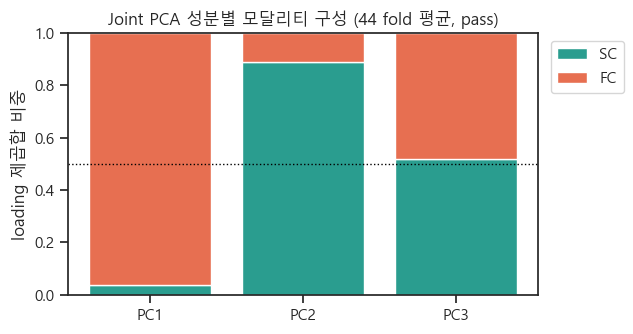


[PC1] 설명분산 34.0%  | SC 비중 0.04
   lh_insula_fc (+0.13), rh_precentral_fc (+0.13), rh_inferiorparietal_fc (+0.13), rh_insula_fc (+0.13), lh_superiortemporal_fc (+0.12), lh_precentral_fc (+0.12), lh_supramarginal_fc (+0.12), rh_superiortemporal_fc (+0.12)

[PC2] 설명분산 8.4%  | SC 비중 0.89
   rh_Hippocampus_sc (+0.19), lh_rostralanteriorcingulate_sc (+0.17), lh_Hippocampus_sc (+0.17), lh_lateralorbitofrontal_sc (+0.17), lh_superiorfrontal_sc (+0.17), lh_superiortemporal_sc (+0.16), rh_middletemporal_sc (+0.16), rh_inferiortemporal_sc (+0.16)

[PC3] 설명분산 5.6%  | SC 비중 0.52
   lh_frontalpole_fc (+0.20), lh_inferiortemporal_sc (+0.19), rh_temporalpole_fc (+0.18), lh_superiorparietal_sc (+0.17), rh_frontalpole_fc (+0.17), rh_medialorbitofrontal_fc (+0.17), rh_superiorparietal_sc (+0.16), lh_temporalpole_fc (+0.16)


In [9]:
# ==========================================================
# 8. Joint PCA 성분 구성 — 각 PC가 SC / FC 중 어디서 왔나
#    PC loading 제곱합을 SC 84개 / FC 84개 몫으로 나눈 비중. 0.5면 반반, 1이면 SC 전용.
#    위쪽 표·그림은 CV 안에서 fold마다 fit한 PCA 값을 모은 것이다.
# ==========================================================
share = np.array(sc_share_log)   # (44 folds, N_PCA)
pcs = [f'PC{k + 1}' for k in range(N_PCA)]
tab = pd.DataFrame({'SC 비중': share.mean(0), 'FC 비중': 1 - share.mean(0),
                    'SC min': share.min(0), 'SC max': share.max(0)}, index=pcs)
display(tab.round(3))

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(pcs, tab['SC 비중'], color='#2A9D8F', label='SC')
ax.bar(pcs, tab['FC 비중'], bottom=tab['SC 비중'], color='#E76F51', label='FC')
ax.axhline(0.5, color='black', ls=':', lw=1)
ax.set_ylim(0, 1)
ax.set_ylabel('loading 제곱합 비중')
ax.set_title(f'Joint PCA 성분별 모달리티 구성 (44 fold 평균, {SC_RULE})')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 참고: 44명 전체로 한 번 fit한 Joint PCA의 PC별 상위 loading ---
#     vas를 쓰지 않으므로 leakage는 없지만, 기술용이다. 여기서 ROI를 골라 피처로 쓰지 말 것.
all_idx = np.arange(len(y))
Zs_all, _ = resid_scale(X_sc, X_nuis_sc, all_idx, all_idx)
Zf_all, _ = resid_scale(X_fc, X_nuis_fc, all_idx, all_idx)
pca_all = PCA(n_components=N_PCA, random_state=42).fit(np.hstack([Zs_all, Zf_all]))
feat_names = [f'{r}_sc' for r in ROIS] + [f'{r}_fc' for r in ROIS]
for k, pc in enumerate(pcs):
    ld = pd.Series(pca_all.components_[k], index=feat_names)
    top = ld.abs().sort_values(ascending=False).head(8).index
    print(f'\n[{pc}] 설명분산 {pca_all.explained_variance_ratio_[k]:.1%}  '
          f'| SC 비중 {(ld.iloc[:N_SC] ** 2).sum():.2f}')
    print('   ' + ', '.join(f'{f} ({ld[f]:+.2f})' for f in top))

## 결과 읽는 법

1. **Joint가 따로 PCA보다 나은가**: `d_Joint_vs_Multi`가 +면 Joint_PCA3 오차가 더 작다.
   단 Joint는 뇌 피처 3개, Multimodal은 6개라 **차원 수도 같이 달라진 비교**다.
   Joint가 이기면 "결합 방식" 덕인지 "피처가 적어서 과적합이 줄어서"인지 이 비교만으로는 못 가른다.
2. **Joint가 단일 모달리티보다 나은가**: `d_Joint_vs_SC`, `d_Joint_vs_FC84` **둘 다** +여야 결합 이득.
   셋 다 뇌 피처 3개라 이 비교는 차원 수가 같다.
3. **8번 셀의 성분 구성과 같이 읽기**: PC가 한쪽으로 쏠려 있으면 (예: FC 비중 > 0.8)
   Joint_PCA3는 사실상 그 모달리티의 PCA3다. 그러면 성능도 그쪽 단일 PCA3와 비슷하게 나오는 게 정상이고,
   "멀티모달 결합"이라고 부르기 어렵다.
4. **Active와 Sham**: 5번 셀과 10번 셀에서 군별 RMSE, r, R2를 나란히 본다. 모델은 44명 전체로 학습한 것이다.
5. **연결 기준**: pass가 주 분석이다. end에서 방향이 다르면 결론이 연결 기준에 달려 있다는 뜻이고, 그렇게 적는다.
6. **재현성 확인**: `SC_PCA3`, `FC84_PCA3`, `Multimodal`의 RMSE는 같은 연결 기준의 coupling 노트북과 같아야 한다.
7. **하지 말 것**: 모달리티 블록에 가중치를 줘서 비중을 맞추거나, 좋게 나온 연결 기준만 골라 보고하는 것.


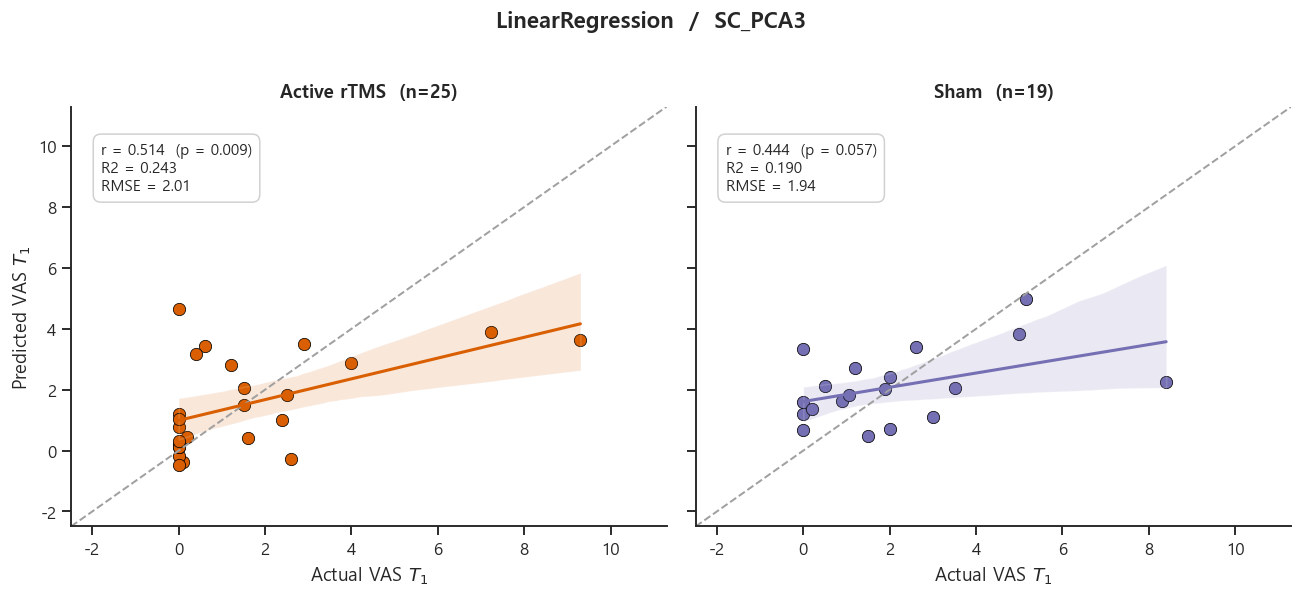

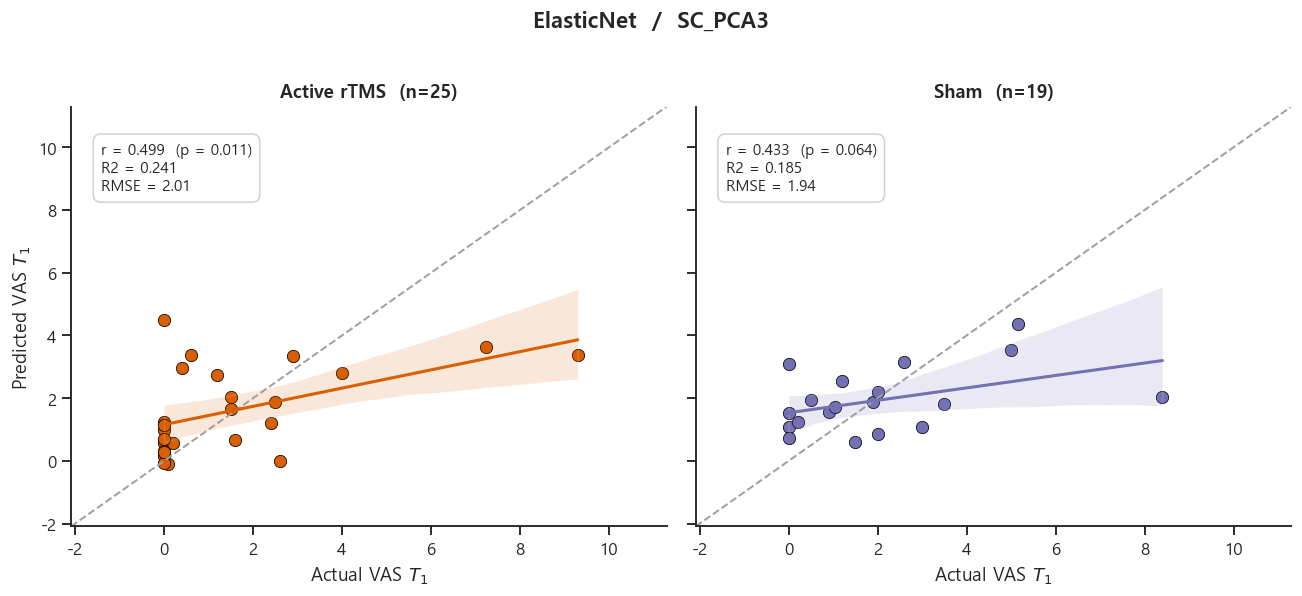

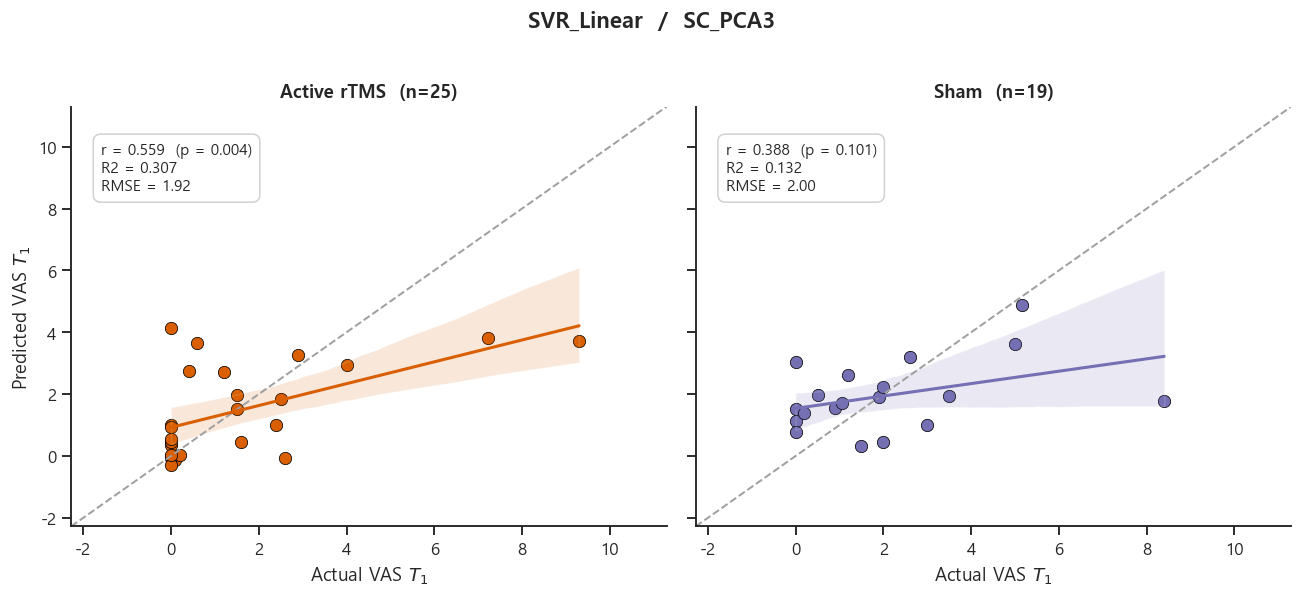

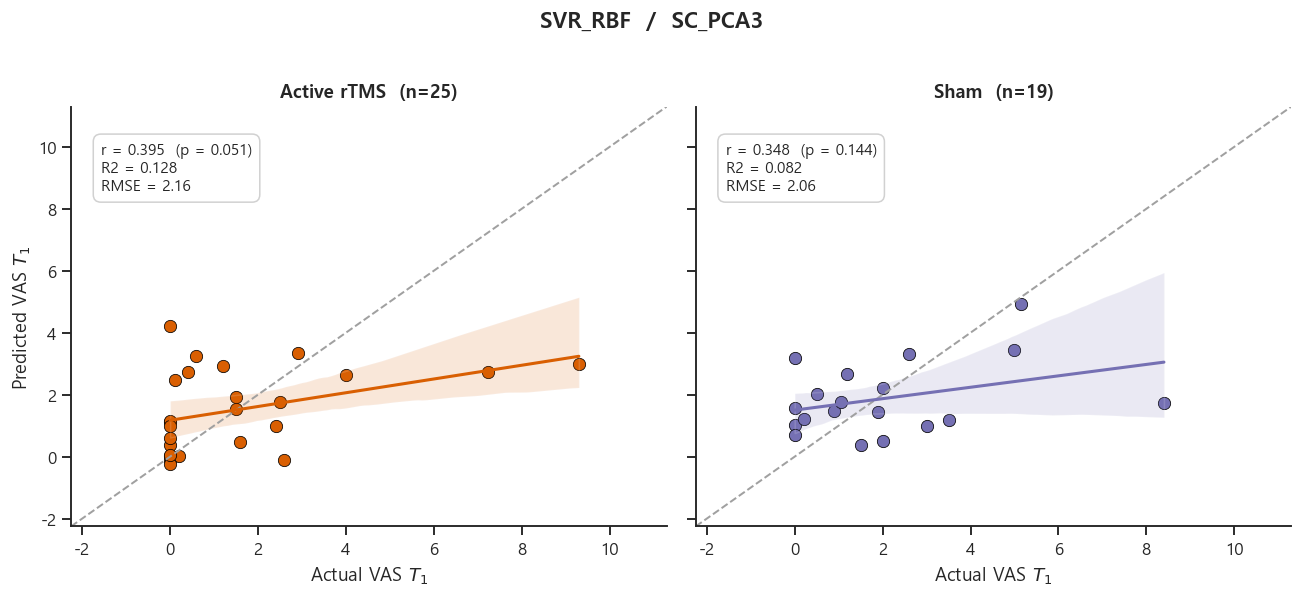

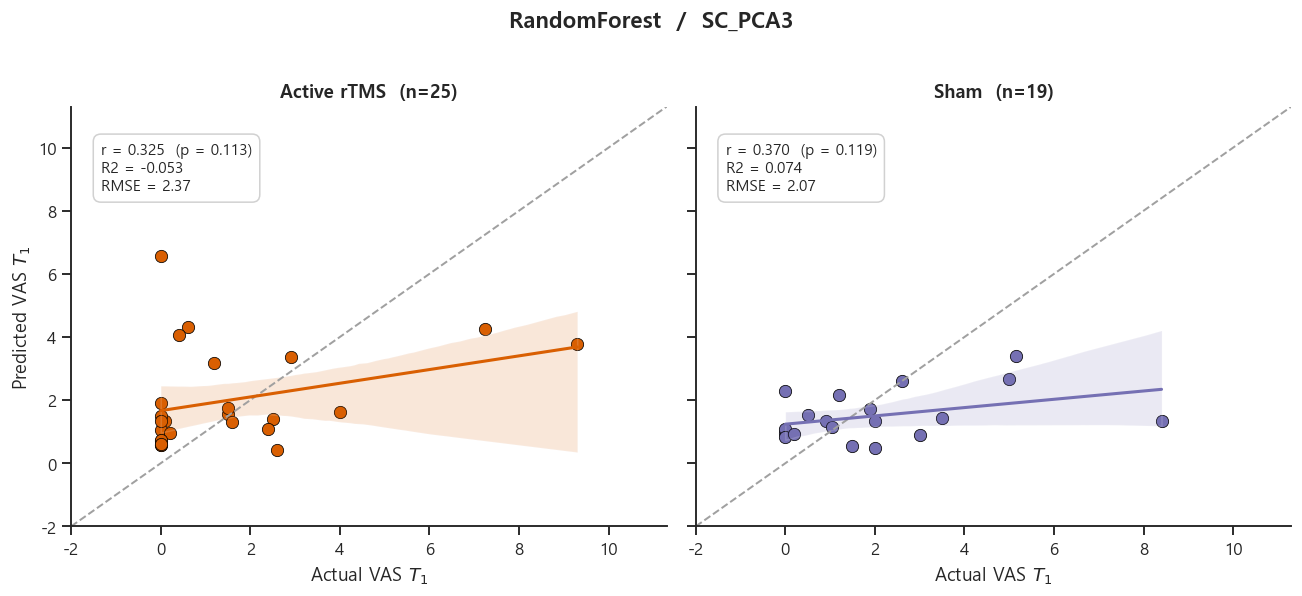

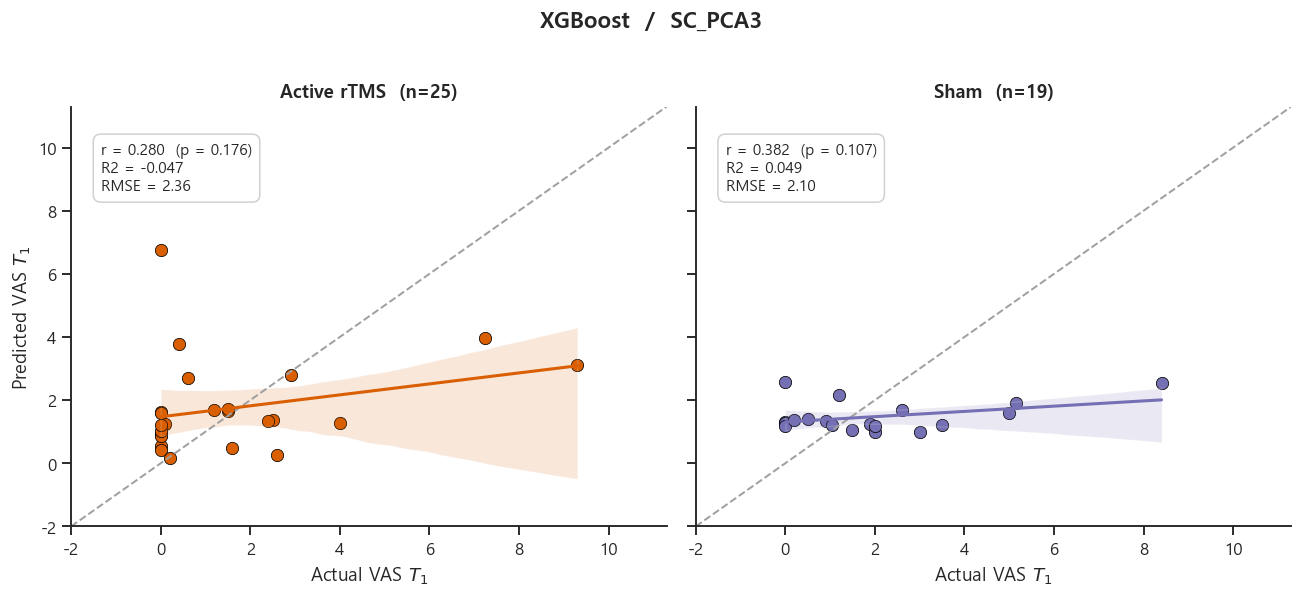

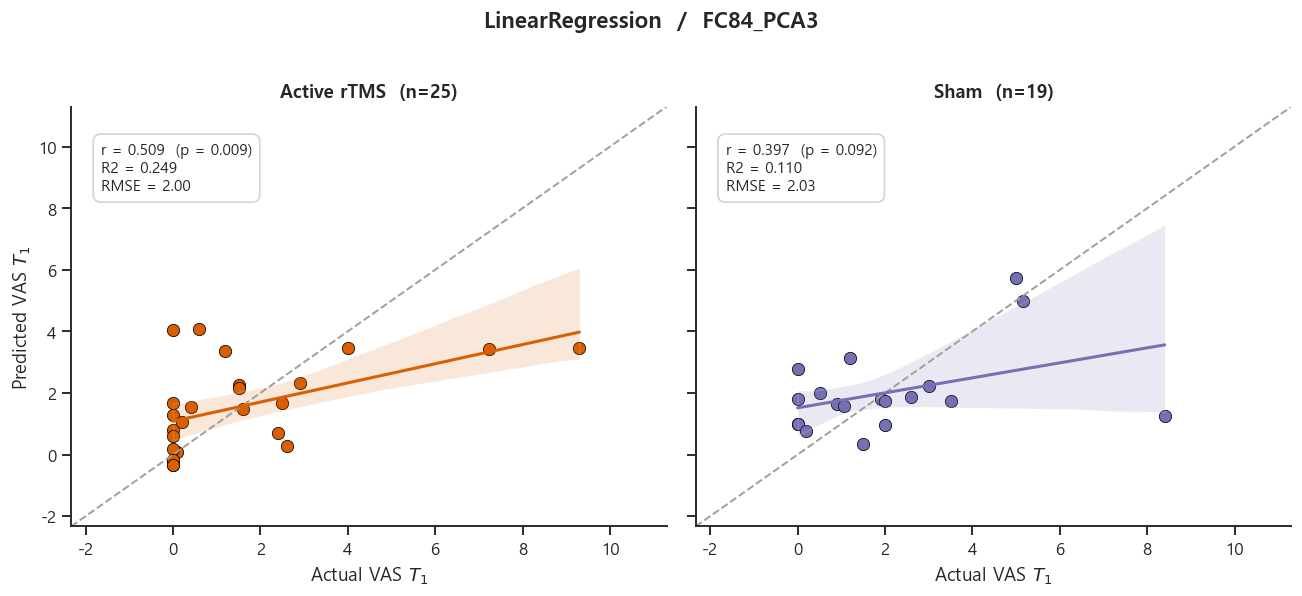

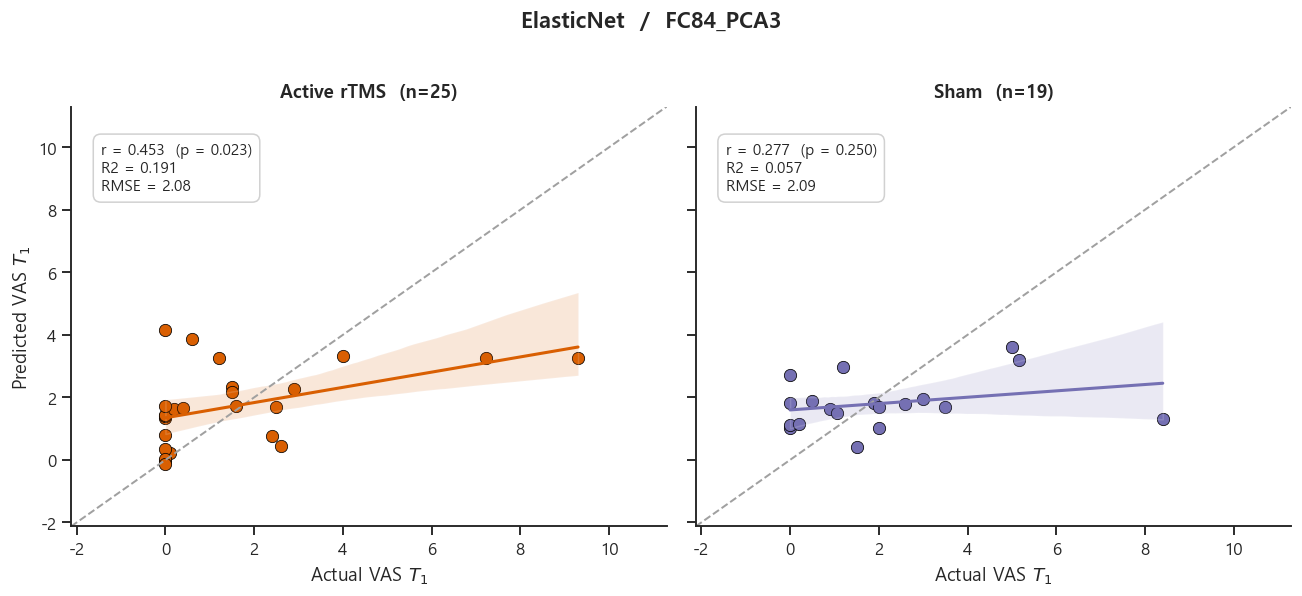

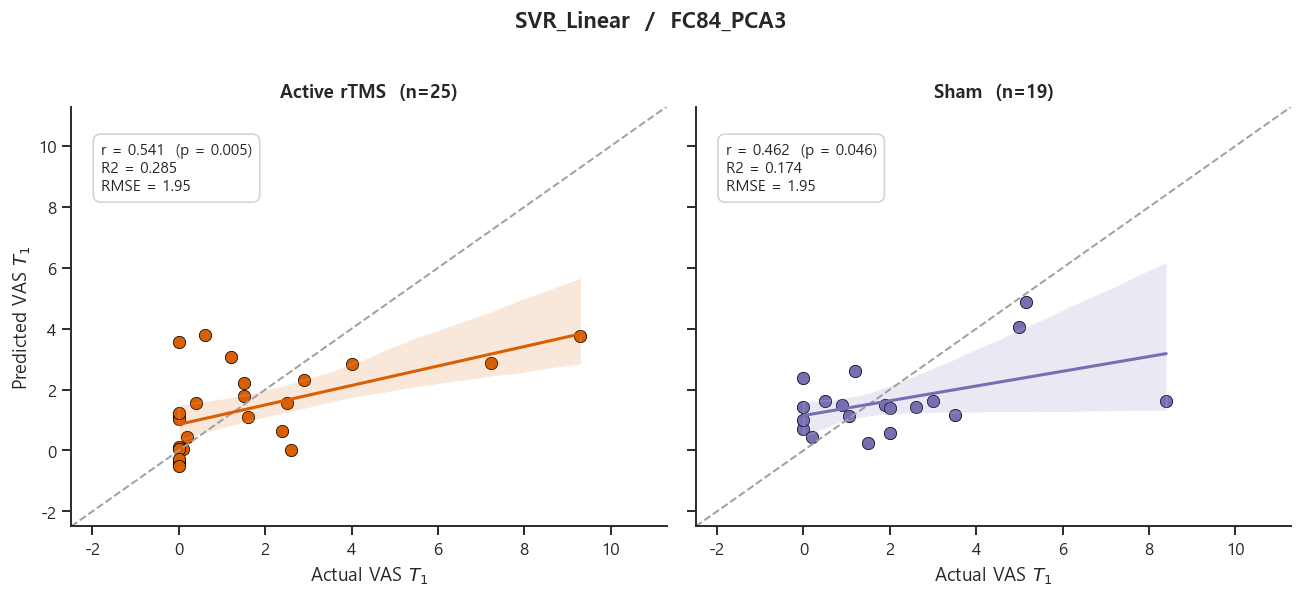

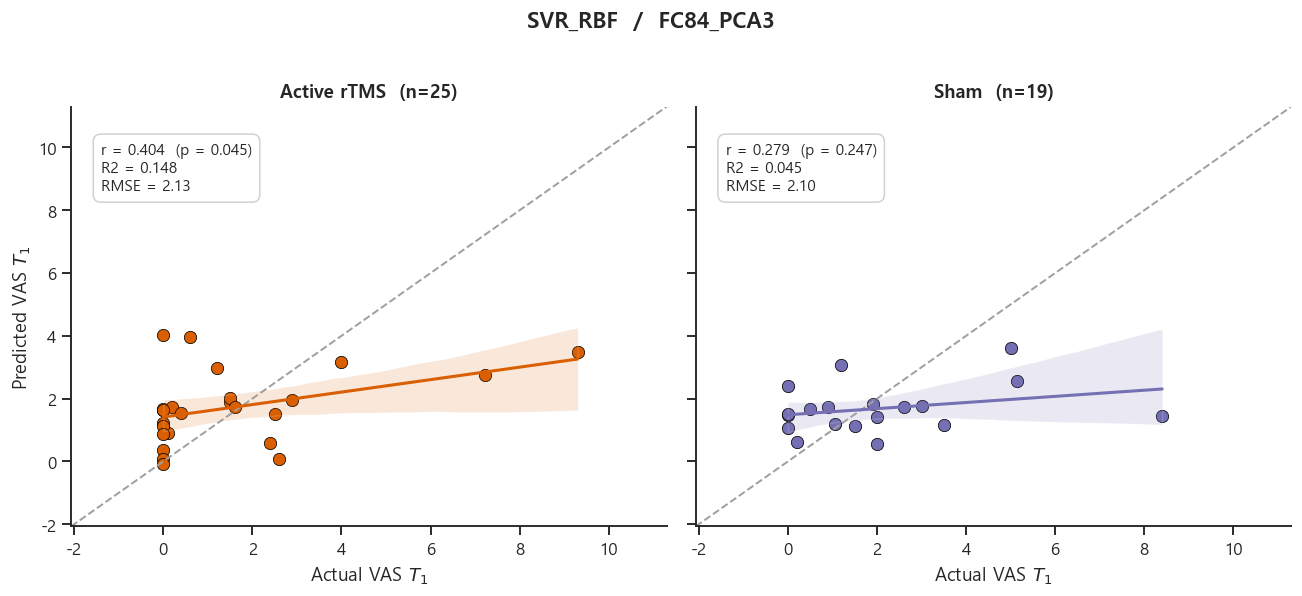

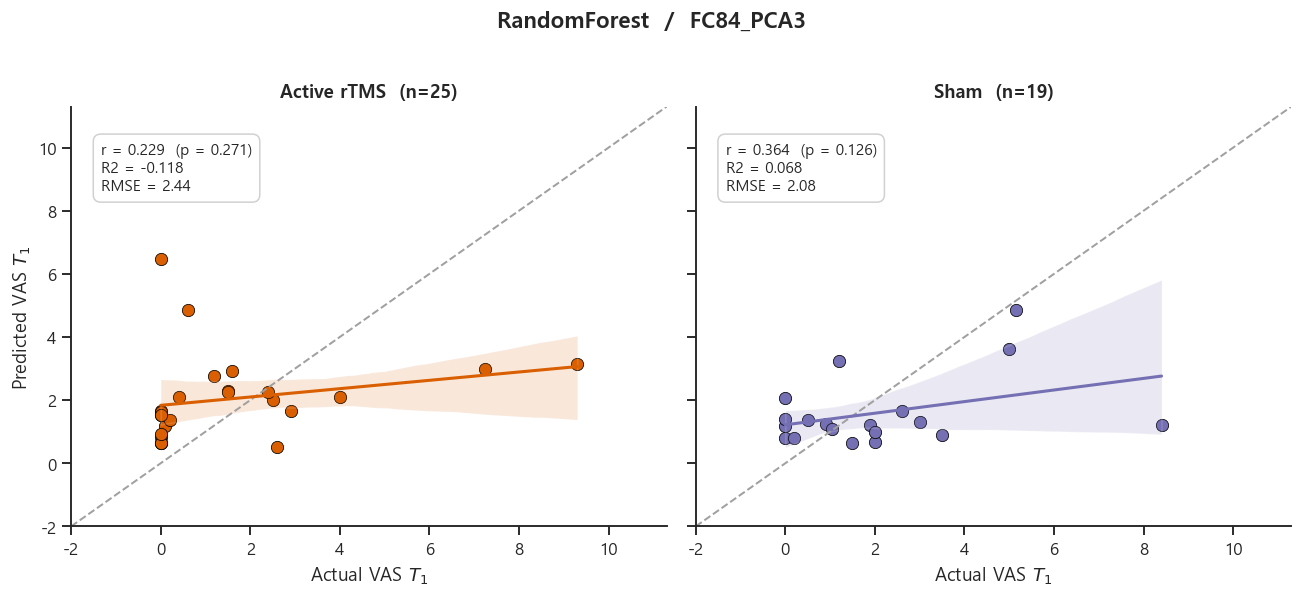

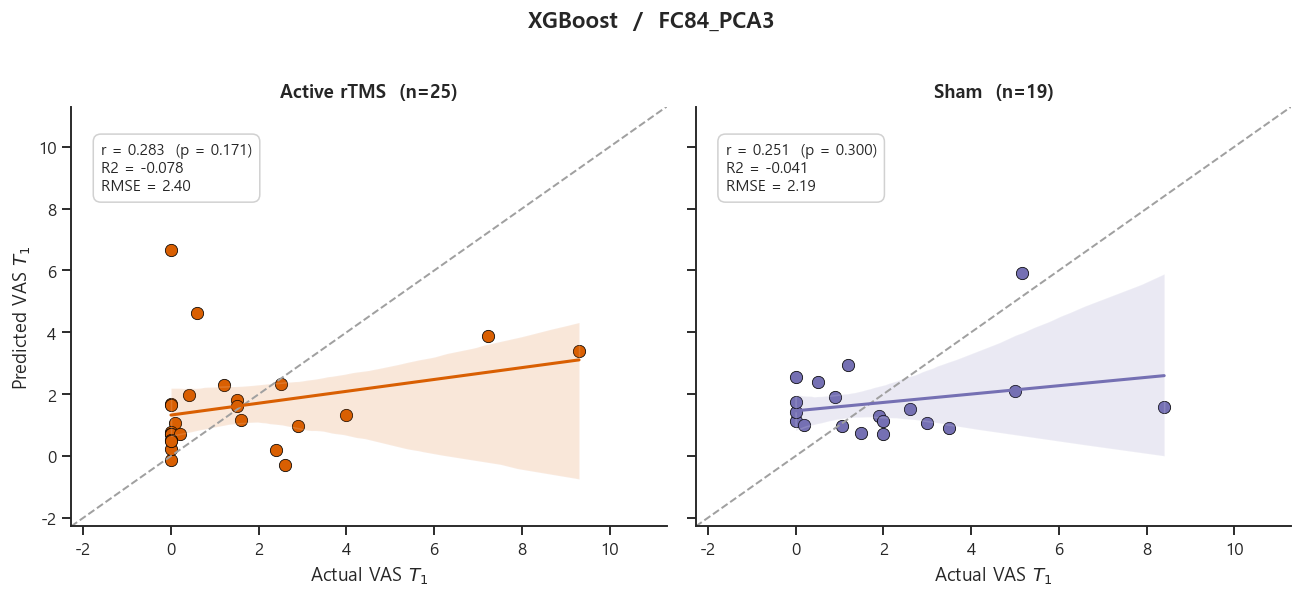

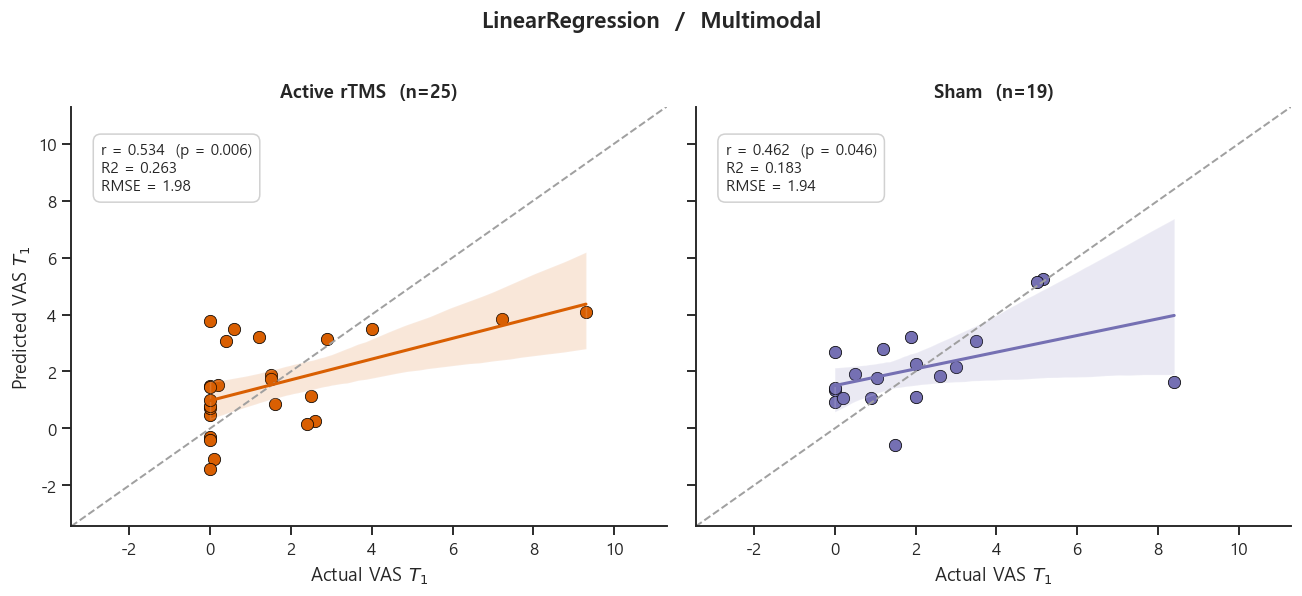

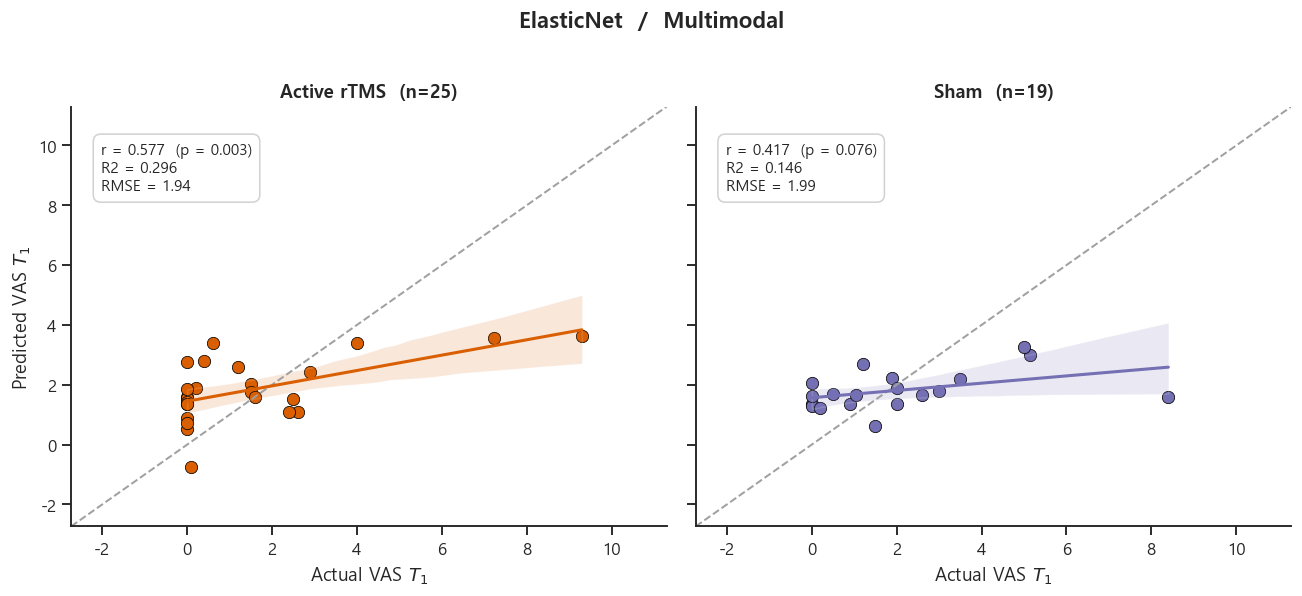

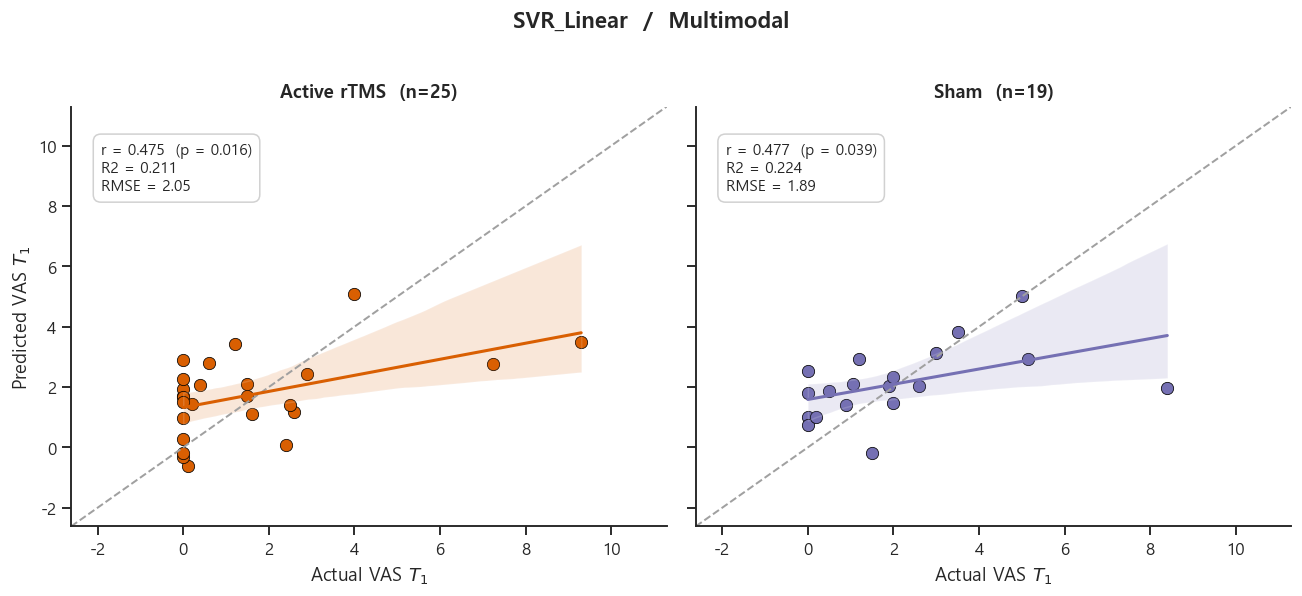

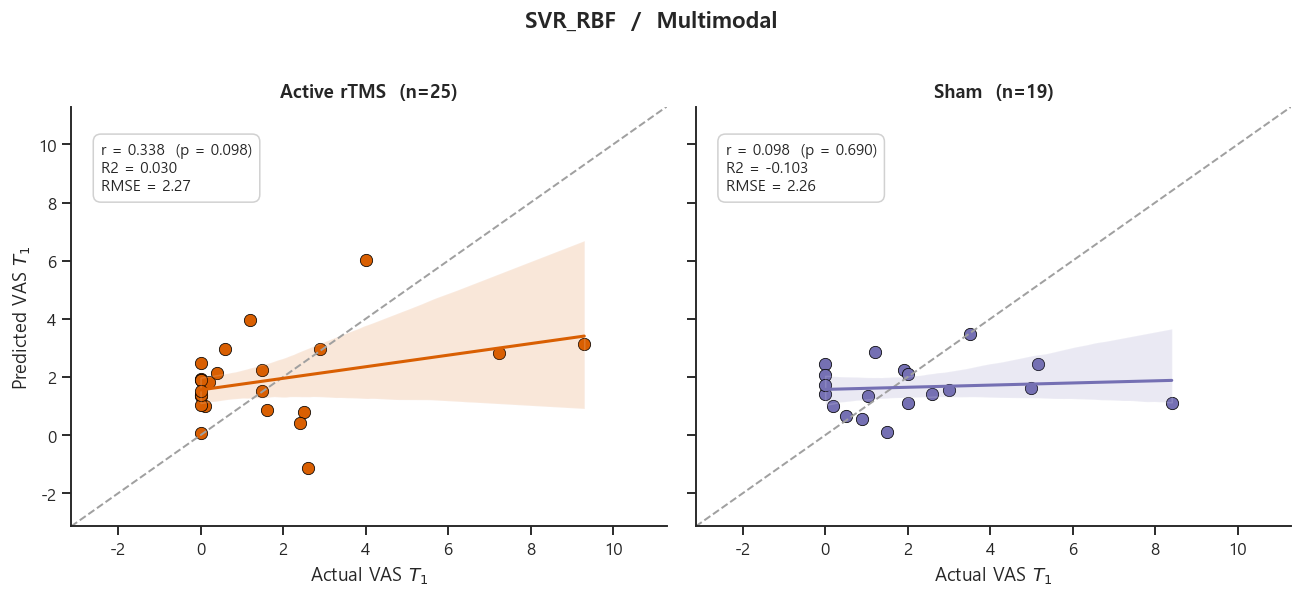

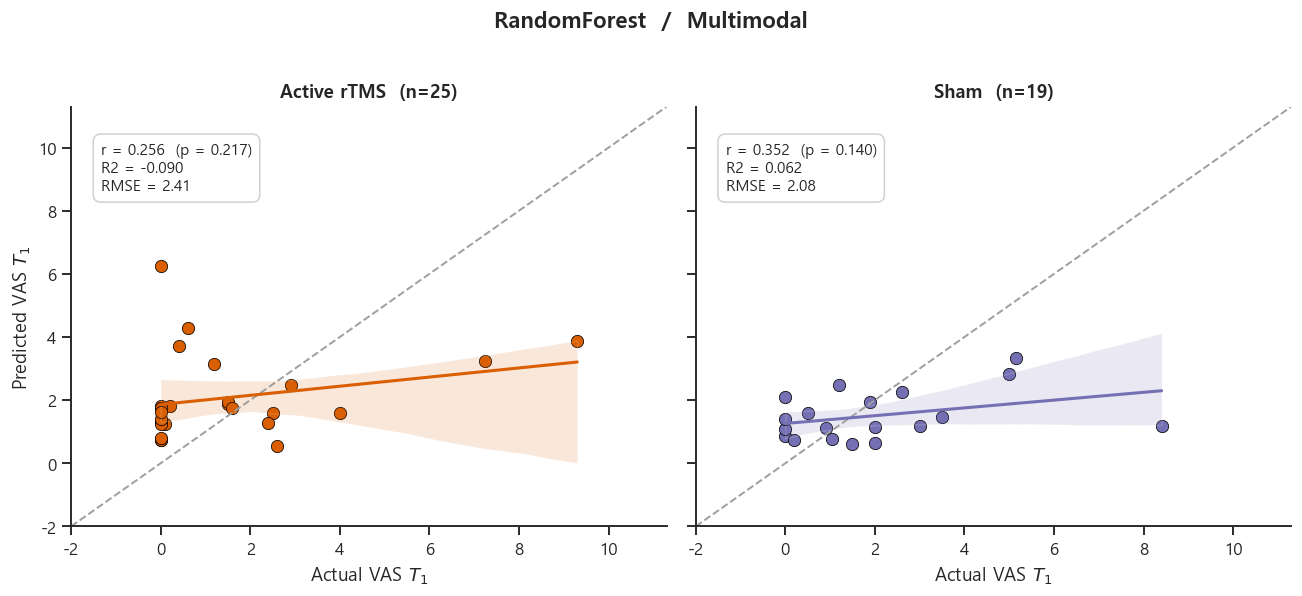

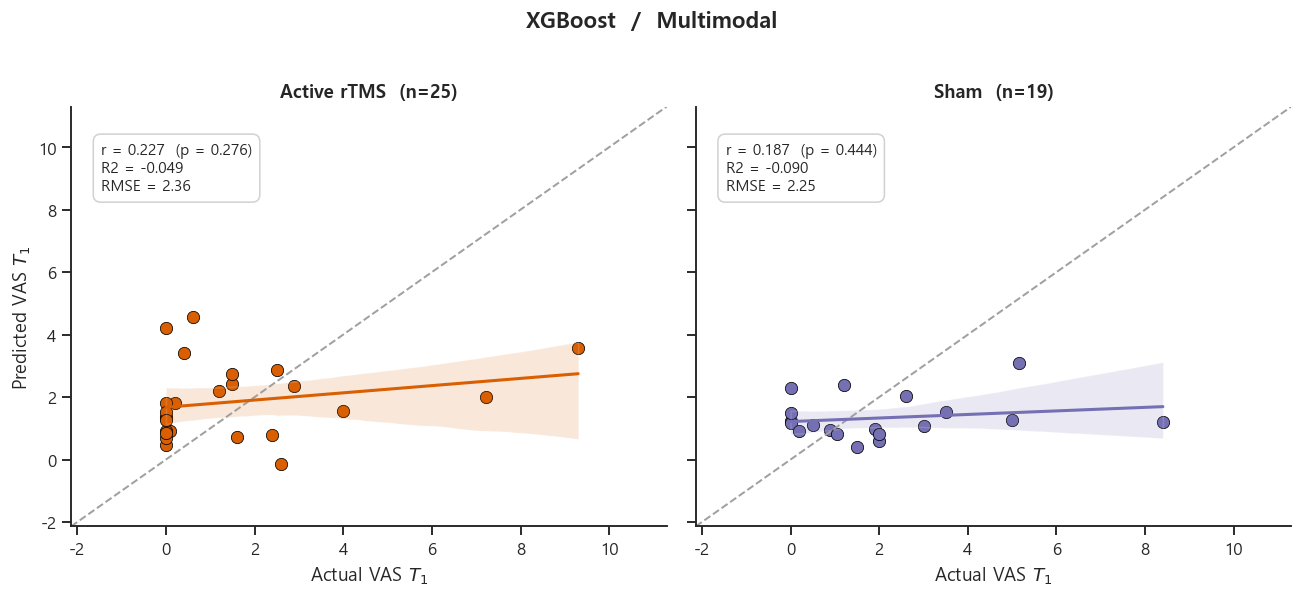

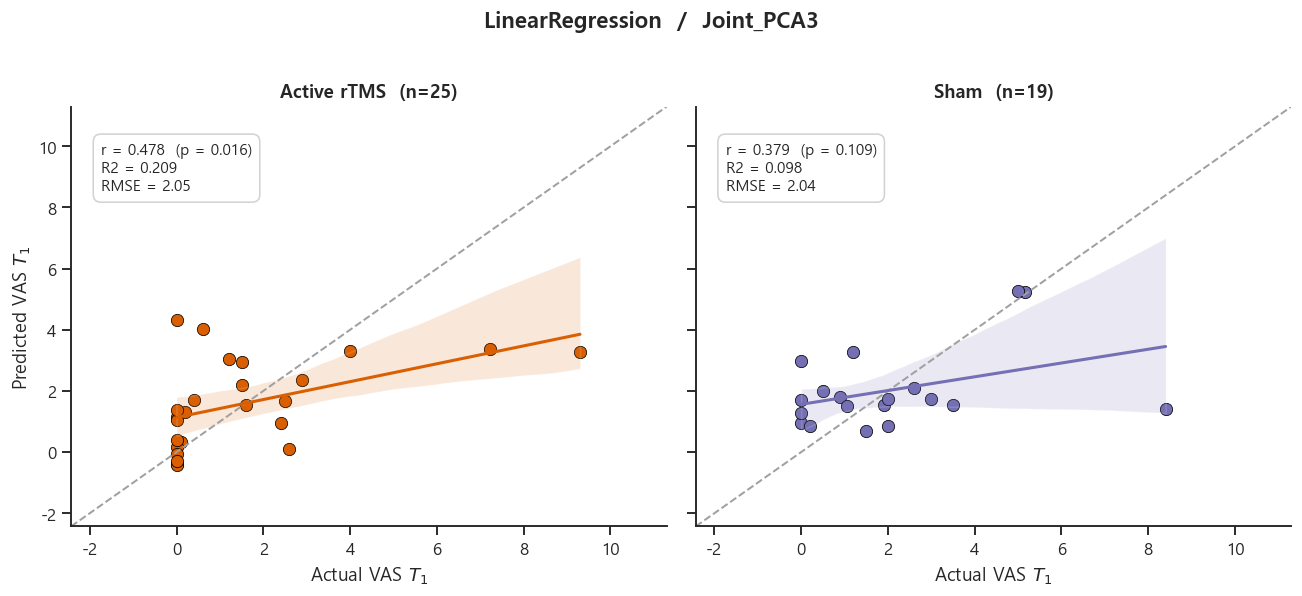

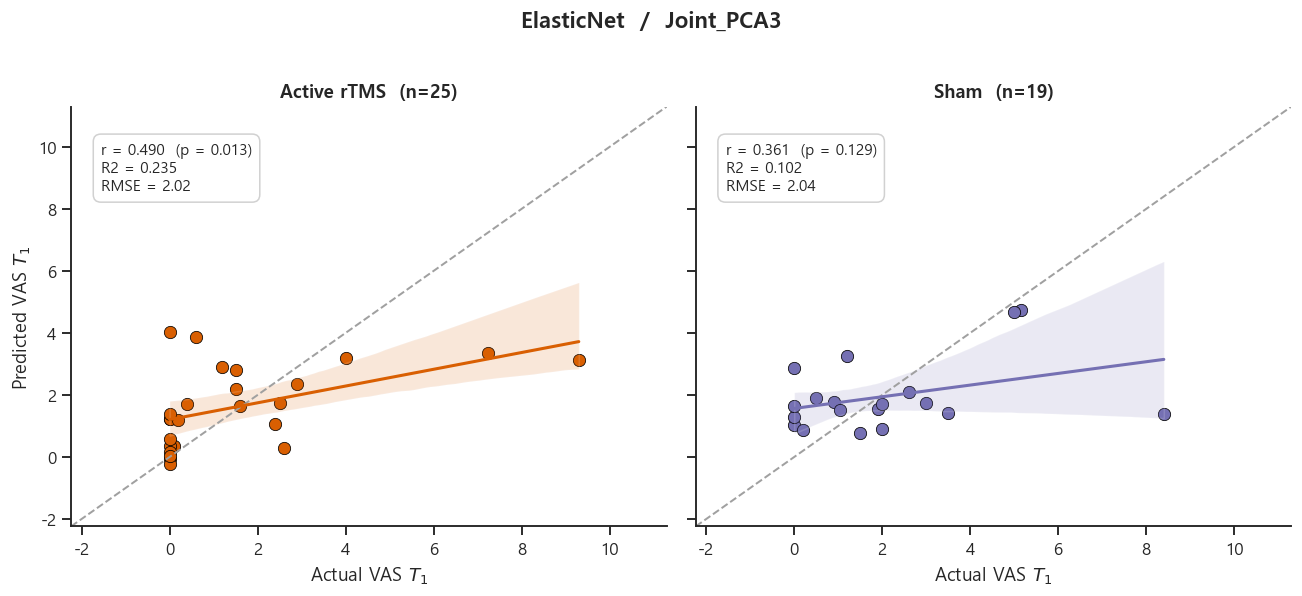

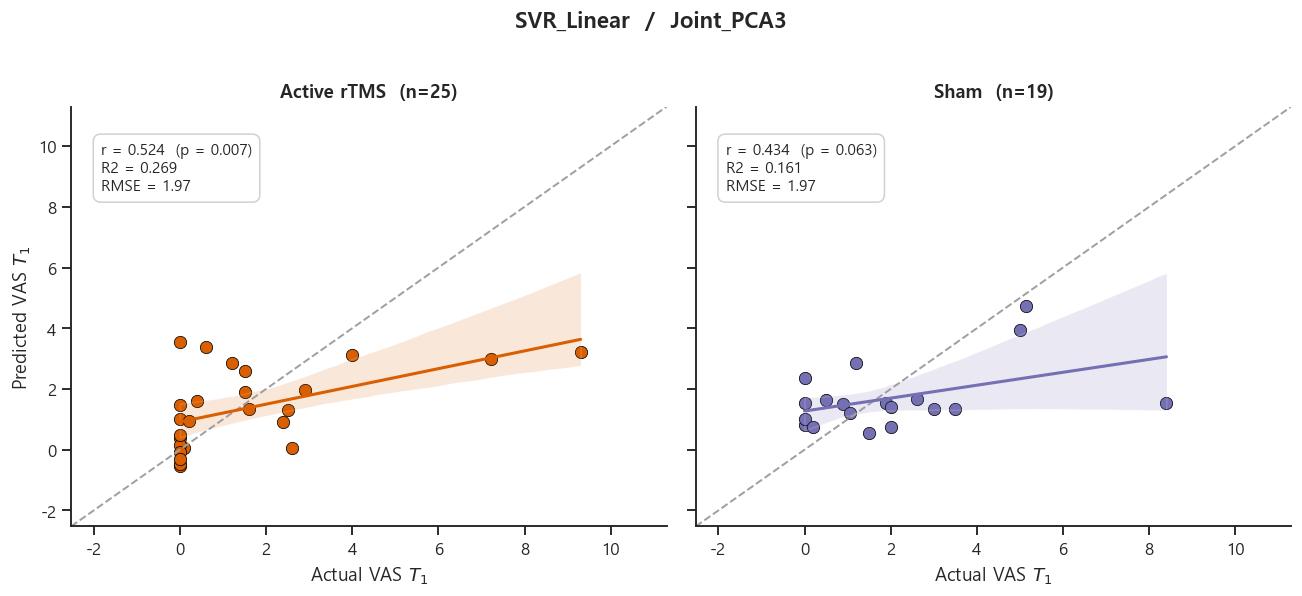

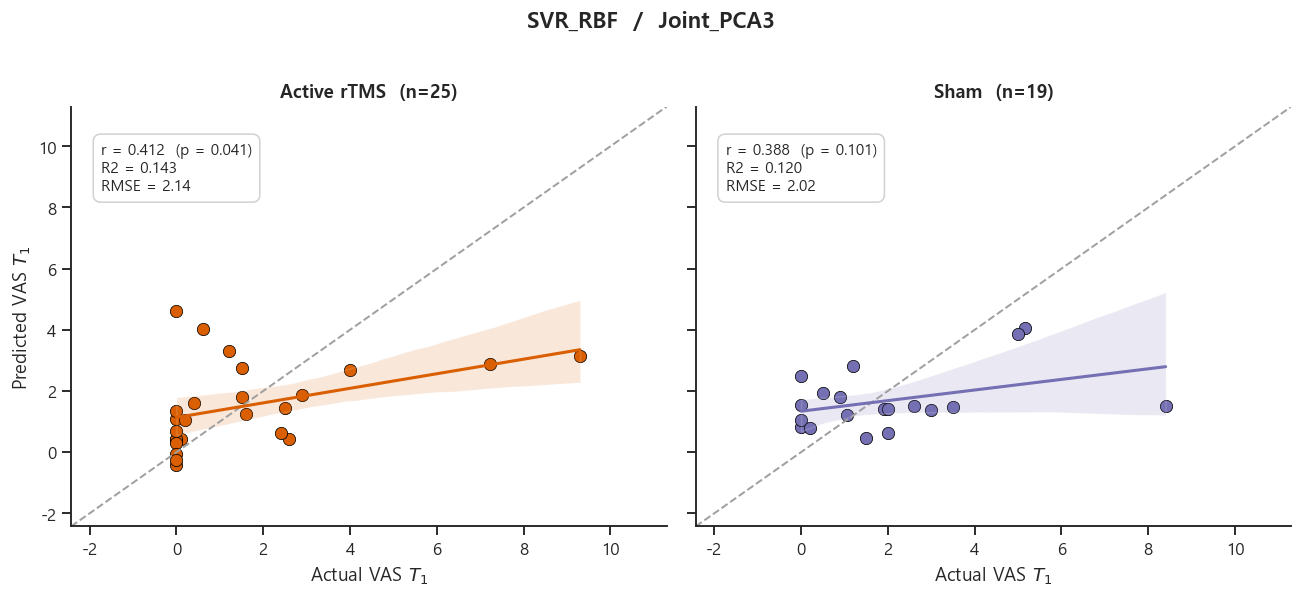

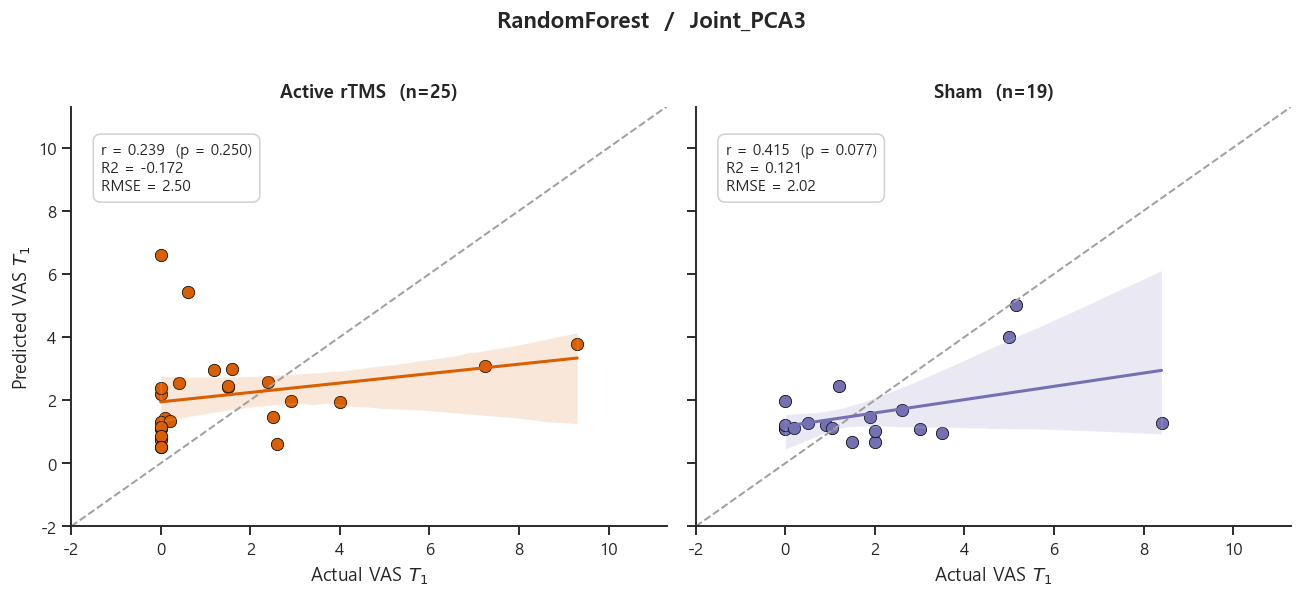

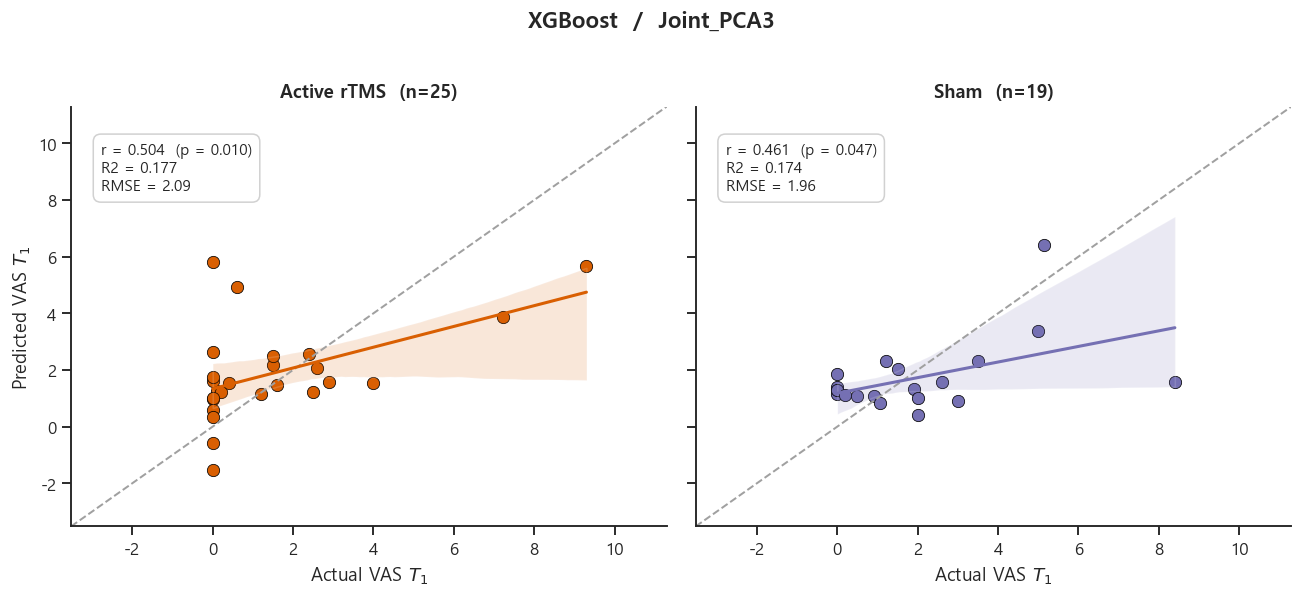

In [10]:
# ==========================================================
# 9. 산점도 — Active rTMS vs Sham 분리 (기존 멀티모달 노트북 8번 셀과 동일한 형식)
#    LOOCV 예측은 44명 전체로 학습한 것이고, 그림에서만 그룹을 나눠 본다.
# ==========================================================
PLOT_DATA_TYPES = ['SC_PCA3', 'FC84_PCA3', 'Multimodal', 'Joint_PCA3']   # 줄이려면 여기서 빼기
groups2 = ['Active rTMS', 'Sham']
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
grp_full = np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')

for (dt, name), preds in predictions.items():
    if dt not in PLOT_DATA_TYPES:
        continue
    yp = np.array(preds)
    pdf = pd.DataFrame({'Actual': y_true, 'Predicted': yp, 'Group': grp_full})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True, dpi=110)
    lo = min(pdf['Actual'].min(), pdf['Predicted'].min()) - 2
    hi = max(pdf['Actual'].max(), pdf['Predicted'].max()) + 2
    for i, g in enumerate(groups2):
        ax = axes[i]
        sub = pdf[pdf['Group'] == g]
        r, pv = pearsonr(sub['Actual'], sub['Predicted'])
        ax.plot([lo, hi], [lo, hi], color='#A0A0A0', ls='--', lw=1.3)
        sns.scatterplot(data=sub, x='Actual', y='Predicted', color=palette[g], s=65,
                        edgecolor='black', linewidth=0.5, ax=ax)
        sns.regplot(data=sub, x='Actual', y='Predicted', ax=ax, scatter=False,
                    color=palette[g], line_kws={'linewidth': 2})
        ax.set_title(f'{g}  (n={len(sub)})', fontweight='bold')
        ax.text(0.05, 0.80,
                f"r = {r:.3f}  (p = {pv:.3f})\n"
                f"R2 = {r2_score(sub['Actual'], sub['Predicted']):.3f}\n"
                f"RMSE = {np.sqrt(np.mean((sub['Actual'] - sub['Predicted']) ** 2)):.2f}",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#CCC', alpha=0.9))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual VAS $T_1$')
        if i == 0:
            ax.set_ylabel('Predicted VAS $T_1$')
    fig.suptitle(f'{name}  /  {dt}', fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [11]:
# ==========================================================
# 10. 산점도 결과 표 — 9번 셀의 r / R2 / RMSE 를 모델별로 정리
#     (그림에 찍힌 값과 같은 숫자다. 눈으로 비교하기 어려우니 표로 모은다)
# ==========================================================
rows_sc = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_sc.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

sc = pd.DataFrame(rows_sc)
sc['Data Type'] = pd.Categorical(sc['Data Type'], DATA_TYPES)
sc['Model'] = pd.Categorical(sc['Model'], list(models))

# --- 넓은 표: 행 = 피처셋 x 모델, 열 = Active/Sham x 지표 ---
wide = sc.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

# --- 좁은 표: RMSE와 r만, 두 군을 나란히 ---
print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

# --- 군별로 가장 좋았던 조합 ---
print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(sc[sc.Group == g].sort_values('RMSE')[['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 19명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                          Active                        Sham         \
                                 RMSE     R2      r      p   RMSE     R2   
Data Type     Model                                                        
Clinical_ONLY LinearRegression  2.004  0.246  0.507  0.010  1.989  0.145   
              ElasticNet        2.003  0.247  0.507  0.010  1.988  0.146   
              SVR_Linear        2.055  0.207  0.475  0.016  2.022  0.117   
              SVR_RBF           2.291  0.015  0.358  0.079  2.095  0.052   
              RandomForest      2.261  0.040  0.356  0.081  2.118  0.031   
              XGBoost           2.341 -0.029  0.319  0.120  2.089  0.058   
SC_PCA3       LinearRegression  2.009  0.243  0.514  0.009  1.937  0.190   
              ElasticNet        2.010  0.241  0.499  0.011  1.943  0.185   
              SVR_Linear        1.922  0.307  0.559  0.004  2.005  0.132   
              SVR_RBF           2.155  0.128  0.395  0.051  2.061  0.082   
              RandomForest      2.368 -0.053  0.325  0.113  2.071  0.074   
              XGBoost           2.362 -0.047  0.280  0.176  2.098  0.049   
FC84_PCA3     LinearRegression  2.000  0.249  0.509  0.009  2.029  0.110   
              ElasticNet        2.075  0.191  0.453  0.023  2.090  0.057   
              SVR_Linear        1.952  0.285  0.541  0.005  1.955  0.174   
              SVR_RBF           2.130  0.148  0.404  0.045  2.103  0.045   
              RandomForest      2.440 -0.118  0.229  0.271  2.077  0.068   
              XGBoost           2.396 -0.078  0.283  0.171  2.195 -0.041   
Multimodal    LinearRegression  1.981  0.263  0.534  0.006  1.944  0.183   
              ElasticNet        1.936  0.296  0.577  0.003  1.988  0.146   
              SVR_Linear        2.050  0.211  0.475  0.016  1.895  0.224   
              SVR_RBF           2.273  0.030  0.338  0.098  2.259 -0.103   
              RandomForest      2.409 -0.090  0.256  0.217  2.084  0.062   
              XGBoost           2.363 -0.049  0.227  0.276  2.246 -0.090   
Joint_PCA3    LinearRegression  2.052  0.209  0.478  0.016  2.043  0.098   
              ElasticNet        2.019  0.235  0.490  0.013  2.039  0.102   
              SVR_Linear        1.973  0.269  0.524  0.007  1.971  0.161   
              SVR_RBF           2.137  0.143  0.412  0.041  2.018  0.120   
              RandomForest      2.498 -0.172  0.239  0.250  2.017  0.121   
              XGBoost           2.093  0.177  0.504  0.010  1.955  0.174   

Group                                         
                                    r      p  
Data Type     Model                           
Clinical_ONLY LinearRegression  0.402  0.088  
              ElasticNet        0.402  0.088  
              SVR_Linear        0.400  0.090  
              SVR_RBF           0.329  0.170  
              RandomForest      0.302  0.209  
              XGBoost           0.307  0.202  
SC_PCA3       LinearRegression  0.444  0.057  
              ElasticNet        0.433  0.064  
              SVR_Linear        0.388  0.101  
              SVR_RBF           0.348  0.144  
              RandomForest      0.370  0.119  
              XGBoost           0.382  0.107  
FC84_PCA3     LinearRegression  0.397  0.092  
              ElasticNet        0.277  0.250  
              SVR_Linear        0.462  0.046  
              SVR_RBF           0.279  0.247  
              RandomForest      0.364  0.126  
              XGBoost           0.251  0.300  
Multimodal    LinearRegression  0.462  0.046  
              ElasticNet        0.417  0.076  
              SVR_Linear        0.477  0.039  
              SVR_RBF           0.098  0.690  
              RandomForest      0.352  0.140  
              XGBoost           0.187  0.444  
Joint_PCA3    LinearRegression  0.379  0.109  
              ElasticNet        0.361  0.129  
              SVR_Linear        0.434  0.063  
              SVR_RBF           0.388  0.101  
              RandomForest      0.


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  r_Sham  \
Data Type     Model                                                        
Clinical_ONLY LinearRegression        2.004      1.989     0.507   0.402   
              ElasticNet              2.003      1.988     0.507   0.402   
              SVR_Linear              2.055      2.022     0.475   0.400   
              SVR_RBF                 2.291      2.095     0.358   0.329   
              RandomForest            2.261      2.118     0.356   0.302   
              XGBoost                 2.341      2.089     0.319   0.307   
SC_PCA3       LinearRegression        2.009      1.937     0.514   0.444   
              ElasticNet              2.010      1.943     0.499   0.433   
              SVR_Linear              1.922      2.005     0.559   0.388   
              SVR_RBF                 2.155      2.061     0.395   0.348   
              RandomForest            2.368      2.071     0.325   0.370   
              XGBoost                 2.362      2.098     0.280   0.382   
FC84_PCA3     LinearRegression        2.000      2.029     0.509   0.397   
              ElasticNet              2.075      2.090     0.453   0.277   
              SVR_Linear              1.952      1.955     0.541   0.462   
              SVR_RBF                 2.130      2.103     0.404   0.279   
              RandomForest            2.440      2.077     0.229   0.364   
              XGBoost                 2.396      2.195     0.283   0.251   
Multimodal    LinearRegression        1.981      1.944     0.534   0.462   
              ElasticNet              1.936      1.988     0.577   0.417   
              SVR_Linear              2.050      1.895     0.475   0.477   
              SVR_RBF                 2.273      2.259     0.338   0.098   
              RandomForest            2.409      2.084     0.256   0.352   
              XGBoost                 2.363      2.246     0.227   0.187   
Joint_PCA3    LinearRegression        2.052      2.043     0.478   0.379   
              ElasticNet              2.019      2.039     0.490   0.361   
              SVR_Linear              1.973      1.971     0.524   0.434   
              SVR_RBF                 2.137      2.018     0.412   0.388   
              RandomForest            2.498      2.017     0.239   0.415   
              XGBoost                 2.093      1.955     0.504   0.461   

                                RMSE_diff  
Data Type     Model                        
Clinical_ONLY LinearRegression      0.015  
              ElasticNet            0.015  
              SVR_Linear            0.033  
              SVR_RBF               0.196  
              RandomForest          0.143  
              XGBoost               0.252  
SC_PCA3       LinearRegression      0.072  
              ElasticNet            0.068  
              SVR_Linear           -0.083  
              SVR_RBF               0.094  
              RandomForest          0.298  
              XGBoost               0.264  
FC84_PCA3     LinearRegression     -0.029  
              ElasticNet           -0.015  
              SVR_Linear           -0.003  
              SVR_RBF               0.027  
              RandomForest          0.363  
              XGBoost               0.201  
Multimodal    LinearRegression      0.037  
              ElasticNet           -0.052  
              SVR_Linear            0.156  
              SVR_RBF               0.014  
              RandomForest          0.325  
              XGBoost               0.118  
Joint_PCA3    LinearRegression      0.009  
              ElasticNet           -0.020  
              SVR_Linear            0.002  
              SVR_RBF               0.118  
              RandomForest          0.482  
              XGBoost               0.138


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,RMSE,R2,r,p
0,SC_PCA3,SVR_Linear,1.922,0.307,0.559,0.004
1,Multimodal,ElasticNet,1.936,0.296,0.577,0.003
2,FC84_PCA3,SVR_Linear,1.952,0.285,0.541,0.005
3,Joint_PCA3,SVR_Linear,1.973,0.269,0.524,0.007
4,Multimodal,LinearRegression,1.981,0.263,0.534,0.006



[Sham]


,Data Type,Model,RMSE,R2,r,p
0,Multimodal,SVR_Linear,1.895,0.224,0.477,0.039
1,SC_PCA3,LinearRegression,1.937,0.190,0.444,0.057
2,SC_PCA3,ElasticNet,1.943,0.185,0.433,0.064
3,Multimodal,LinearRegression,1.944,0.183,0.462,0.046
4,FC84_PCA3,SVR_Linear,1.955,0.174,0.462,0.046
